# AlphaZero: Mastering Chess and Shogi by Self-Play**Paper:** [Mastering Chess and Shogi by Self-Play with a General Reinforcement Learning Algorithm](https://arxiv.org/abs/1712.01815)  **Authors:** Silver et al. (DeepMind, 2017/2018)This notebook implements a **simplified AlphaZero** — MCTS guided by a neural network, trained entirely by self-play reinforcement learning — on the game of **Connect Four**. The core algorithm (PUCT-based MCTS + policy-value network + self-play training) faithfully follows the paper, scaled down to run on a single GPU in minutes.

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cuda


## 2. Game Environment: Connect FourA from-scratch implementation of Connect Four (6×7 board). The game is chosen for its small action space (7 columns) and short game length (~20 moves), making AlphaZero's self-play loop tractable on a single GPU.

In [2]:
class Connect4:
    """Connect Four game on a 6x7 board. Player 1 = X, Player -1 = O."""
    
    ROWS, COLS = 6, 7
    WIN = 4
    
    def __init__(self):
        self.board = np.zeros((self.ROWS, self.COLS), dtype=np.float32)
        self.current_player = 1  # 1 or -1
    
    def get_valid_moves(self):
        return [c for c in range(self.COLS) if self.board[0, c] == 0]
    
    def play(self, col):
        """Drop piece in column col. Returns True if move was legal."""
        for r in range(self.ROWS - 1, -1, -1):
            if self.board[r, col] == 0:
                self.board[r, col] = self.current_player
                self.current_player *= -1
                return True
        return False
    
    def is_terminal(self):
        return self._check_win() is not None or len(self.get_valid_moves()) == 0
    
    def _check_win(self):
        """Returns 1 or -1 if that player won, 0 if draw, None if ongoing."""
        for r in range(self.ROWS):
            for c in range(self.COLS):
                if self.board[r, c] == 0:
                    continue
                player = self.board[r, c]
                # Check horizontal, vertical, diagonal
                for dr, dc in [(0,1), (1,0), (1,1), (1,-1)]:
                    count = 0
                    for i in range(self.WIN):
                        nr, nc = r + dr*i, c + dc*i
                        if 0 <= nr < self.ROWS and 0 <= nc < self.COLS and self.board[nr, nc] == player:
                            count += 1
                        else:
                            break
                    if count >= self.WIN:
                        return int(player)
        return None
    
    def get_reward(self):
        """Returns reward from current_player's perspective at terminal."""
        winner = self._check_win()
        if winner is None:
            return 0  # draw
        return winner  # 1 or -1
    
    def board_to_tensor(self):
        """Encode board as (2, ROWS, COLS) tensor: plane 0 = current player pieces, plane 1 = opponent."""
        t = np.zeros((2, self.ROWS, self.COLS), dtype=np.float32)
        t[0] = (self.board == self.current_player).astype(np.float32)
        t[1] = (self.board == -self.current_player).astype(np.float32)
        return torch.tensor(t, device=device).unsqueeze(0)
    
    def clone(self):
        g = Connect4()
        g.board = self.board.copy()
        g.current_player = self.current_player
        return g


In [3]:
# Quick game test
g = Connect4()
g.play(3); g.play(3); g.play(3); g.play(3)
print(g.board)
print("Terminal:", g.is_terminal(), "Reward:", g.get_reward())


[[ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.]]
Terminal: False Reward: 0


## 3. Neural Network: PolicyValueNetA dual-headed CNN that outputs (policy, value) = fθ(s), matching AlphaZero's architecture:- **Shared trunk:** 2 conv layers (32 filters, 3×3, ReLU) — simplified from the paper's 19/39-block ResNet- **Policy head:** outputs logits over 7 actions (columns)- **Value head:** outputs scalar in [−1, 1] via tanh

In [4]:
class PolicyValueNet(nn.Module):
    """Dual-headed CNN: shared conv trunk -> policy head + value head."""
    
    def __init__(self, rows=6, cols=7, n_actions=7):
        super().__init__()
        # Shared trunk
        self.conv1 = nn.Conv2d(2, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(32)
        
        # Policy head
        self.pi_conv = nn.Conv2d(32, 16, 1)  # 1x1 conv
        self.pi_bn = nn.BatchNorm2d(16)
        self.pi_fc = nn.Linear(16 * rows * cols, n_actions)
        
        # Value head
        self.v_conv = nn.Conv2d(32, 8, 1)  # 1x1 conv
        self.v_bn = nn.BatchNorm2d(8)
        self.v_fc1 = nn.Linear(8 * rows * cols, 64)
        self.v_fc2 = nn.Linear(64, 1)
    
    def forward(self, x):
        # Shared trunk
        h = F.relu(self.bn1(self.conv1(x)))
        h = F.relu(self.bn2(self.conv2(h)))
        
        # Policy head
        pi = F.relu(self.pi_bn(self.pi_conv(h)))
        pi = pi.view(pi.size(0), -1)
        pi_logits = self.pi_fc(pi)
        
        # Value head
        v = F.relu(self.v_bn(self.v_conv(h)))
        v = v.view(v.size(0), -1)
        v = F.relu(self.v_fc1(v))
        v = torch.tanh(self.v_fc2(v))
        
        return pi_logits, v
    
    def predict(self, board_tensor):
        """Single-position prediction. Returns (policy_probs, value)."""
        self.eval()
        with torch.no_grad():
            pi, v = self.forward(board_tensor)
            probs = F.softmax(pi, dim=1)
        return probs.squeeze(0).cpu().numpy(), v.item()


## 4. MCTS with Neural Network GuidanceImplements the PUCT-based MCTS from the paper:- **Selection:** a = argmax Q(s,a) + c_puct · P(s,a) · √N(s) / (1 + N(s,a))- **Expansion:** evaluate leaf with network → create children with priors- **Backup:** propagate value (negated for opponent) up the path

In [5]:
class MCTSNode:
    """A node in the MCTS search tree."""
    
    def __init__(self, state, parent=None, prior=0.0, action=None):
        self.state = state
        self.parent = parent
        self.action = action  # action that led to this node
        self.children = {}
        self.untried_actions = state.get_valid_moves()
        self.N = 0  # visit count
        self.W = 0.0  # total value
        self.P = prior  # prior probability from network
        self.is_expanded = False
    
    @property
    def Q(self):
        return self.W / self.N if self.N > 0 else 0.0
    
    def ucb_score(self, c_puct=1.0):
        """PUCT selection score."""
        parent_N = self.parent.N if self.parent else 1
        return self.Q + c_puct * self.P * (np.sqrt(parent_N) / (1 + self.N))
    
    def best_child(self, c_puct=1.0):
        """Select child with highest PUCT score."""
        return max(self.children.values(), key=lambda c: c.ucb_score(c_puct))


In [6]:
class MCTS:
    """Monte Carlo Tree Search guided by a neural network."""
    
    def __init__(self, network, c_puct=1.0, dirichlet_alpha=0.3, dirichlet_eps=0.25):
        self.network = network
        self.c_puct = c_puct
        self.dirichlet_alpha = dirichlet_alpha
        self.dirichlet_eps = dirichlet_eps
    
    def search(self, root_state, num_simulations=100):
        """Run MCTS from root_state. Returns root node with populated tree."""
        root = MCTSNode(root_state.clone())
        
        # Add Dirichlet noise to root for exploration
        probs, value = self.network.predict(root_state.board_to_tensor())
        valid = root_state.get_valid_moves()
        noise = np.random.dirichlet([self.dirichlet_alpha] * len(valid))
        noisy_probs = np.zeros(7)
        for i, a in enumerate(valid):
            noisy_probs[a] = (1 - self.dirichlet_eps) * probs[a] + self.dirichlet_eps * noise[i]
        
        # Expand root
        for a in valid:
            child_state = root_state.clone()
            child_state.play(a)
            root.children[a] = MCTSNode(child_state, parent=root, prior=noisy_probs[a], action=a)
        root.untried_actions = []
        root.is_expanded = True
        root.N = 1
        
        for _ in range(num_simulations):
            node = self._select(root)
            value = self._evaluate(node)
            self._backup(node, value)
        
        return root
    
    def _select(self, root):
        """Traverse tree to a leaf using PUCT."""
        node = root
        while node.is_expanded and not node.state.is_terminal():
            node = node.best_child(self.c_puct)
        return node
    
    def _evaluate(self, node):
        """Evaluate a leaf node with the network."""
        if node.state.is_terminal():
            # Terminal: return actual reward (from the perspective of the player who just moved)
            reward = node.state.get_reward()
            # The player who just moved is the opponent of current_player
            return -reward * node.state.current_player  # negate for the mover's perspective
        
        # Non-terminal leaf: expand using network prediction
        probs, value = self.network.predict(node.state.board_to_tensor())
        valid = node.state.get_valid_moves()
        
        # Normalize probs over valid moves
        valid_probs = np.array([probs[a] for a in valid])
        valid_probs = valid_probs / (valid_probs.sum() + 1e-8)
        
        for i, a in enumerate(valid):
            child_state = node.state.clone()
            child_state.play(a)
            node.children[a] = MCTSNode(child_state, parent=node, prior=valid_probs[i], action=a)
        
        node.untried_actions = []
        node.is_expanded = True
        
        # Value is from current_player's perspective; we need the mover's perspective
        return -value
    
    def _backup(self, node, value):
        """Backup value up the tree, flipping sign at each level."""
        while node is not None:
            node.N += 1
            node.W += value
            value = -value  # flip for opponent's perspective
            node = node.parent
    
    def get_action_probs(self, root, temperature=1.0):
        """Return policy proportional to visit counts^1/temperature."""
        visits = np.array([root.children[a].N if a in root.children else 0 for a in range(7)])
        if temperature == 0:
            # Greedy: pick most visited
            probs = np.zeros(7)
            probs[visits.argmax()] = 1.0
        else:
            probs = visits ** (1.0 / temperature)
            probs = probs / (probs.sum() + 1e-8)
        return probs


## 5. Self-PlayGenerate training data by playing games against itself using MCTS. Each move's training example is (board_state, MCTS_policy, final_game_value).

In [7]:
def self_play_game(network, num_simulations=100, temperature_start=10):
    """Play one self-play game. Returns list of (state_tensor, policy, value) tuples."""
    mcts = MCTS(network)
    game = Connect4()
    training_data = []
    move_count = 0
    
    while not game.is_terminal():
        root = mcts.search(game, num_simulations=num_simulations)
        
        # Temperature: explore early, exploit later
        temp = 1.0 if move_count < temperature_start else 0.1
        pi = mcts.get_action_probs(root, temperature=temp)
        
        # Store training example (from current player's perspective)
        state_tensor = game.board_to_tensor().clone()
        training_data.append((state_tensor, pi.copy(), game.current_player))
        
        # Sample action (only from valid moves)
        valid = game.get_valid_moves()
        masked_pi = np.array([pi[a] if a in valid else 0.0 for a in range(7)])
        masked_pi = masked_pi / (masked_pi.sum() + 1e-8)
        action = np.random.choice(7, p=masked_pi)
        
        game.play(action)
        move_count += 1
    
    # Assign final values: z = ±1 from each state's player's perspective
    reward = game.get_reward()
    final_data = []
    for state_tensor, pi, player in training_data:
        z = reward * player  # from the perspective of the player who moved at that state
        final_data.append((state_tensor, pi, z))
    
    return final_data


## 6. Training LoopTrain the network using the combined loss from the paper:- **Policy loss:** cross-entropy between MCTS policy and network policy- **Value loss:** MSE between game outcome and predicted value- **L2 regularization:** c·‖θ‖²Loss = (z − v)² − πᵀ log p + c‖θ‖²

In [8]:
def train_step(network, optimizer, batch, l2_coeff=1e-4):
    """One training step on a batch of (state, policy, value) examples."""
    states = torch.cat([s for s, _, _ in batch])
    policies = torch.tensor(np.array([p for _, p, _ in batch]), dtype=torch.float32, device=device)
    values = torch.tensor(np.array([z for _, _, z in batch]), dtype=torch.float32, device=device).unsqueeze(1)
    
    network.train()
    pi_logits, v = network(states)
    
    # Policy loss: cross-entropy with MCTS visit-count distribution
    log_pi = F.log_softmax(pi_logits, dim=1)
    policy_loss = -torch.sum(policies * log_pi) / len(batch)
    
    # Value loss: MSE
    value_loss = F.mse_loss(v, values)
    
    # L2 regularization
    l2_loss = sum(torch.sum(p ** 2) for p in network.parameters())
    
    total_loss = value_loss + policy_loss + l2_coeff * l2_loss
    
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    return policy_loss.item(), value_loss.item(), total_loss.item()


In [9]:
def evaluate_against_random(network, num_games=20, num_simulations=50):
    """Play against a random-move baseline. Returns win rate."""
    mcts = MCTS(network)
    wins = 0
    for _ in range(num_games):
        game = Connect4()
        network_player = 1  # network always plays first for simplicity
        
        while not game.is_terminal():
            if game.current_player == network_player:
                root = mcts.search(game, num_simulations=num_simulations)
                pi = mcts.get_action_probs(root, temperature=0)  # greedy
                action = pi.argmax()
            else:
                action = np.random.choice(game.get_valid_moves())
            game.play(action)
        
        reward = game.get_reward()
        if reward == network_player:
            wins += 1
    
    return wins / num_games


## 7. Training RunRun AlphaZero self-play training for a few iterations. Each iteration:1. Generate self-play games2. Train the network on collected data3. Evaluate win rate against random player

In [10]:
# Hyperparameters
NUM_ITERATIONS = 3
GAMES_PER_ITER = 20
NUM_SIMULATIONS = 100
BATCH_SIZE = 32
LEARNING_RATE = 0.001
L2_COEFF = 1e-4

network = PolicyValueNet().to(device)
optimizer = optim.Adam(network.parameters(), lr=LEARNING_RATE, weight_decay=L2_COEFF)

win_rates = []
policy_losses = []
value_losses = []
replay_buffer = deque(maxlen=500)  # keep recent self-play data

print("Starting AlphaZero self-play training...")
print(f"  Iterations: {NUM_ITERATIONS}")
print(f"  Games per iteration: {GAMES_PER_ITER}")
print(f"  MCTS simulations per move: {NUM_SIMULATIONS}")
print()

for iteration in range(NUM_ITERATIONS):
    # === Self-play phase ===
    for g in range(GAMES_PER_ITER):
        data = self_play_game(network, num_simulations=NUM_SIMULATIONS)
        replay_buffer.extend(data)
    
    # === Training phase ===
    iter_pi_losses = []
    iter_v_losses = []
    num_train_steps = max(1, len(replay_buffer) // BATCH_SIZE)
    
    for step in range(num_train_steps):
        batch = random.sample(list(replay_buffer), min(BATCH_SIZE, len(replay_buffer)))
        pi_loss, v_loss, total = train_step(network, optimizer, batch, L2_COEFF)
        iter_pi_losses.append(pi_loss)
        iter_v_losses.append(v_loss)
    
    avg_pi = np.mean(iter_pi_losses)
    avg_v = np.mean(iter_v_losses)
    policy_losses.append(avg_pi)
    value_losses.append(avg_v)
    
    # === Evaluation ===
    win_rate = evaluate_against_random(network, num_games=20, num_simulations=50)
    win_rates.append(win_rate)
    
    print(f"Iteration {iteration+1}/{NUM_ITERATIONS}: "
          f"buffer={len(replay_buffer)}, "
          f"pi_loss={avg_pi:.4f}, v_loss={avg_v:.4f}, "
          f"win_rate_vs_random={win_rate:.1%}")

print("\nTraining complete!")


Starting AlphaZero self-play training...
  Iterations: 3
  Games per iteration: 20
  MCTS simulations per move: 100



Iteration 1/3: buffer=500, pi_loss=1.9579, v_loss=0.7404, win_rate_vs_random=95.0%


Iteration 2/3: buffer=500, pi_loss=1.9600, v_loss=0.6226, win_rate_vs_random=95.0%


Iteration 3/3: buffer=500, pi_loss=1.8819, v_loss=0.5541, win_rate_vs_random=100.0%

Training complete!


## 8. Results & Visualization

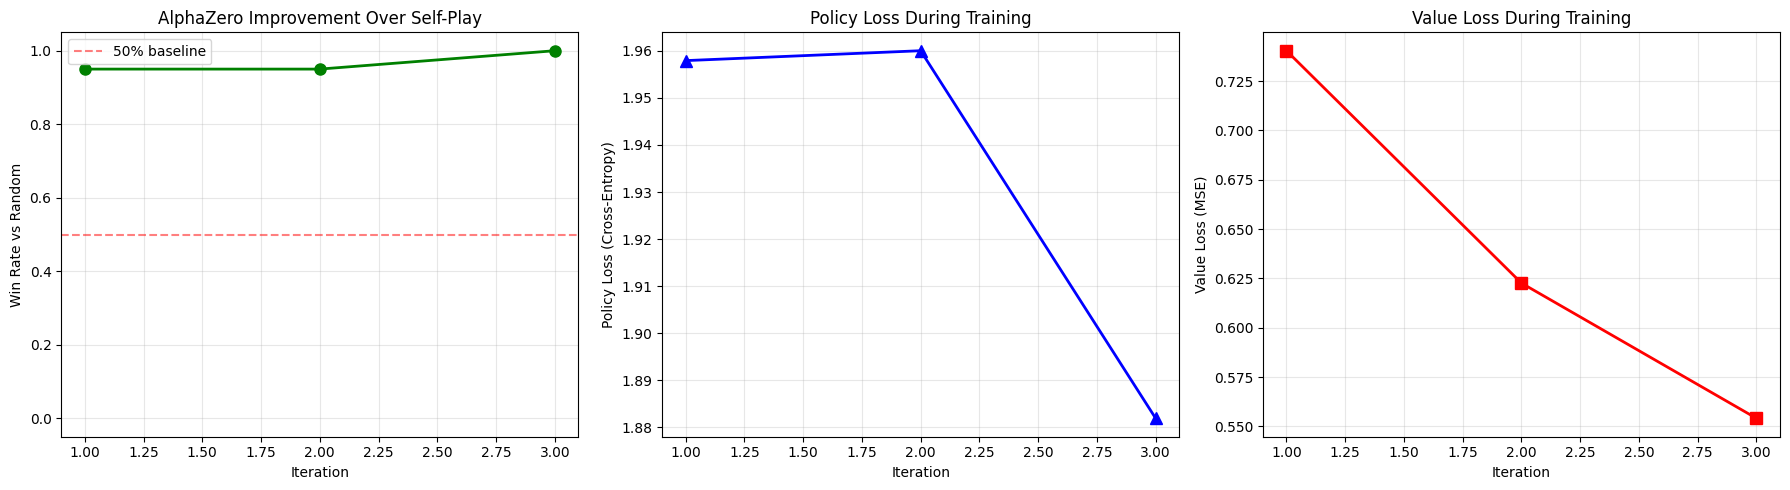

Training curves saved.


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Win rate
axes[0].plot(range(1, len(win_rates)+1), win_rates, 'go-', linewidth=2, markersize=8)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Win Rate vs Random')
axes[0].set_title('AlphaZero Improvement Over Self-Play')
axes[0].set_ylim(-0.05, 1.05)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='50% baseline')
axes[0].legend()

# Policy loss
axes[1].plot(range(1, len(policy_losses)+1), policy_losses, 'b^-', linewidth=2, markersize=8)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Policy Loss (Cross-Entropy)')
axes[1].set_title('Policy Loss During Training')
axes[1].grid(True, alpha=0.3)

# Value loss
axes[2].plot(range(1, len(value_losses)+1), value_losses, 'rs-', linewidth=2, markersize=8)
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Value Loss (MSE)')
axes[2].set_title('Value Loss During Training')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('alphazero_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved.")


## 9. MCTS Search VisualizationShow how MCTS allocates visit counts and Q-values for a sample position, demonstrating the search's focus on promising moves.

In [12]:
# Visualize MCTS on a sample position
sample_game = Connect4()
# Make a few moves to get an interesting position
sample_game.play(3)  # X center
sample_game.play(3)  # O center
sample_game.play(4)  # X
sample_game.play(2)  # O

print("Sample board position:")
print(sample_game.board)
print(f"Current player: {'X' if sample_game.current_player == 1 else 'O'}")
print()

mcts = MCTS(network)
root = mcts.search(sample_game, num_simulations=200)

print("MCTS analysis (200 simulations):")
print(f"{'Column':>8} {'Visits':>8} {'Q-value':>10} {'Prior':>8}")
print("-" * 38)
for a in range(7):
    if a in root.children:
        child = root.children[a]
        print(f"{a:>8} {child.N:>8} {child.Q:>10.4f} {child.P:>8.4f}")
    else:
        print(f"{a:>8} {'---':>8} {'---':>10} {'---':>8}")

best = max(root.children.values(), key=lambda c: c.N)
print(f"\nBest move: column {best.action} ({best.N} visits, Q={best.Q:.4f})")


Sample board position:
[[ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0. -1.  1.  1.  0.  0.]]
Current player: X



MCTS analysis (200 simulations):
  Column   Visits    Q-value    Prior
--------------------------------------
       0        8    -0.3245   0.1697
       1       11    -0.2987   0.1854
       2        3    -0.5172   0.0994
       3      102    -0.1092   0.3662
       4       71    -0.0629   0.0642
       5        3    -0.3475   0.0664
       6        2    -0.3927   0.0487

Best move: column 3 (102 visits, Q=-0.1092)


## SummaryThis notebook implements the core AlphaZero algorithm:1. **MCTS with PUCT selection** — the search tree is guided by the neural network's prior probabilities and value estimates2. **Policy-value network** — a single CNN outputs both move probabilities and position evaluation3. **Self-play reinforcement learning** — the network trains entirely from games played against itself4. **Combined loss** — cross-entropy policy loss + MSE value loss + L2 regularizationThe key insight from the paper: a single, generic algorithm can achieve superhuman performance across multiple games (chess, shogi, Go) without any domain-specific knowledge — just the rules and self-play. Our Connect Four implementation demonstrates this same algorithmic loop at a tractable scale.**Key differences from the full paper:** 2-layer CNN vs 19/39-block ResNet, 100 MCTS simulations vs 800, Connect Four vs chess/shogi/Go, minutes of training vs 24 hours on 5,000 TPUs. The algorithm is identical; only the scale differs.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
